In [1]:
import os
os.chdir(os.getcwd().strip("/notebooks"))
os.chdir(os.getcwd().strip("/examples"))

In [2]:
import torch
import numpy as np
import glob
import json
import cv2
import albumentations as A
from albumentations.pytorch.transforms import ToTensorV2
import onnxruntime as ort
import matplotlib.pyplot as plt

from config import dict_to_config
from src.utils import load_model_inference, keypoint_unscaler
from src.inference import load_fp16_model, process_heatmap_keypoints


def convert_onnx_fp32(folder):
    cfg_path = glob.glob(f"{folder}*.json")[0]
    with open(cfg_path, 'r') as f:
        loaded_dict = json.load(f)
    cfg = dict_to_config(loaded_dict)
    
    load_model_path = glob.glob(f"{folder}*_fp32.pth")[0]
    model = load_model_inference("heatmap", cfg)
    model = load_fp16_model(model, load_model_path, cfg.device)
    model = model.to("cpu")
    model.eval()

    dummy_input = torch.randn(1, 3, cfg.height, cfg.width)
    
    onnx_save_path = os.path.join(cfg.folder, f"{cfg.onnx_save_path}_fp32.onnx")
    torch.onnx.export(
        model,
        dummy_input,
        onnx_save_path,
        export_params=True,
        opset_version=18,
        do_constant_folding=True,
        input_names=["input"],
        output_names=["heatmaps"],
        dynamic_axes={
            "input": {0: "batch_size"},
            "heatmaps": {0: "batch_size"}
        }, dynamo=False
    )
    
    return True


def convert_onnx_fp16(folder):
    """Export FP16 version."""
    if not torch.cuda.is_available():
        print("CUDA not available, skipping FP16 export")
        return
    
    cfg_path = glob.glob(f"{folder}*.json")[0]
    with open(cfg_path, 'r') as f:
        loaded_dict = json.load(f)
    cfg = dict_to_config(loaded_dict)
    
    # Try loading FP16 checkpoint first, fall back to FP32
    fp16_paths = glob.glob(f"{folder}*_fp16.pth")
    fp32_paths = glob.glob(f"{folder}*_fp32.pth")
    
    if fp16_paths:
        load_model_path = fp16_paths[0]
    else:
        load_model_path = fp32_paths[0]
    
    model = load_model_inference("heatmap", cfg)
    model = load_fp16_model(model, load_model_path, cfg.device)
    model = model.half().cuda()
    model.eval()
    
    dummy_input = torch.randn(1, 3, cfg.height, cfg.width).half().cuda()
    
    onnx_save_path = os.path.join(cfg.folder, f"{cfg.onnx_save_path}_fp16.onnx")
    torch.onnx.export(
        model,
        dummy_input,
        onnx_save_path,
        export_params=True,
        opset_version=18,
        do_constant_folding=True,
        input_names=["input"],
        output_names=["heatmaps"], # make as parameter?
        dynamic_axes={
            "input": {0: "batch_size"},
            "heatmaps": {0: "batch_size"}
        }, dynamo=False
    )

if __name__ == "__main__":
    # TODO: create a folder in model map called path_to_model/onnx, then put onnx there or maybe put it in same folder as fp32/fp16, respectively
    folder = "models/resnet34-heatmap"
    
    folder = os.path.join(folder, "")
    # Export FP32
    success = convert_onnx_fp32(folder=folder)
    
    if success:
        convert_onnx_fp16(folder)

c:\Users\nebur\AppData\Local\Programs\Python\Python312\Lib\site-packages\albumentations\__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.6'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()
c:\Users\nebur\OneDrive\Skrivebord\Projects\cv-projects\keypoint-detection\src\inference\processing.py:144: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be al

Loaded model with dtype: fp32
CUDA not available, skipping FP16 export


ONNX model loaded: models/resnet18-hm/heatmap_resnet18_672x448_fp32.onnx
  Providers: ['CUDAExecutionProvider', 'CPUExecutionProvider']


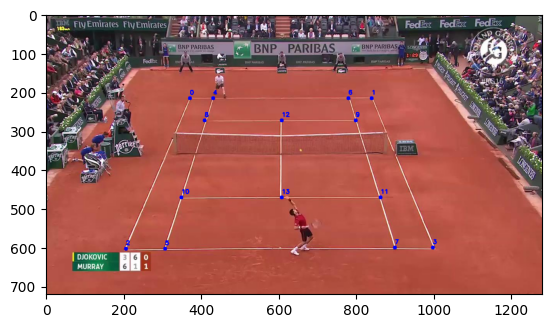

In [14]:
class ONNXPredictor:
    def __init__(self, cfg, onnx_path, use_cuda=True):
        self.cfg = cfg
        
        providers = ["CUDAExecutionProvider", "CPUExecutionProvider"] if use_cuda else ["CPUExecutionProvider"]
        self.session = ort.InferenceSession(onnx_path, providers=providers)
        self.input_name = self.session.get_inputs()[0].name
        
        self.transform = A.Compose([
            A.Resize(width=cfg.width, height=cfg.height),
            A.Normalize(mean=cfg.mean, std=cfg.std),
            ToTensorV2(p=1.0),
        ])
        
        print(f"ONNX model loaded: {onnx_path}")
        print(f"  Providers: {self.session.get_providers()}")

    def predict(self, image_path):
        image = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
        original_h, original_w = image.shape[:2]
        
        transformed = self.transform(image=image)["image"].unsqueeze(0)
        heatmaps = self.session.run(None, {self.input_name: transformed.numpy()})[0]
        
        keypoints = process_heatmap_keypoints(
            cfg=self.cfg,
            keypoints=torch.from_numpy(heatmaps),
            threshold=-2,
            pixel_distance=10,
            image_width=original_w,
            image_height=original_h
        )
        return keypoints

    def predict_frame(self, frame_rgb):
        """For video inference - frame already in RGB."""
        original_h, original_w = frame_rgb.shape[:2]
        
        transformed = self.transform(image=frame_rgb)["image"].unsqueeze(0)
        heatmaps = self.session.run(None, {self.input_name: transformed.numpy()})[0]
        
        keypoints = process_heatmap_keypoints(
            cfg=self.cfg,
            keypoints=torch.from_numpy(heatmaps),
            threshold=-2,
            pixel_distance=10,
            image_width=original_w,
            image_height=original_h
        )
        return keypoints

    def draw_keypoints(self, image, keypoints):
        if keypoints.ndim == 2:
            keypoints = keypoints.flatten()
        if isinstance(image, str):
            image = cv2.cvtColor(cv2.imread(image), cv2.COLOR_BGR2RGB).copy()

        for i in range(0, len(keypoints), 2):
            x, y = int(keypoints[i]), int(keypoints[i+1])
            if x > 0 and y > 0:
                cv2.putText(image, str(i//2), (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)
                cv2.circle(image, (x, y), 5, (0, 0, 255), -1)
        
        plt.imshow(image)
        plt.show()


def load_predictor(folder, onnx_path, use_cuda=True):
    """Helper to load predictor with config from folder."""
    cfg_path = glob.glob(f"{folder}*.json")[0]
    with open(cfg_path, 'r') as f:
        cfg = dict_to_config(json.load(f))
    return ONNXPredictor(cfg, onnx_path, use_cuda)


if __name__ == "__main__":
    folder = "models/resnet18-hm/"
    predictor = load_predictor(
        folder=folder,
        onnx_path=f"{folder}heatmap_resnet18_672x448_fp32.onnx"
    )
    
    keypoints = predictor.predict("dataset/sample_images/clay.jpg")
    predictor.draw_keypoints("dataset/sample_images/clay.jpg", keypoints)